In [ ]:
import pickle
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader


def prepare_dataset(filepath):
    with open(filepath, 'rb') as f:
        raw_data = pickle.load(f)
    
    data_list = []
    for item in raw_data:
        # 转化节点特征 (x)
        x = torch.tensor(item['x'], dtype=torch.float)
        # 转化边索引 (edge_index) 并转置为 [2, E] 形状
        edge_index = torch.tensor(item['edge_index'], dtype=torch.long).t().contiguous()
        # 转化专家特征 (u)
        u = torch.tensor([item['u']], dtype=torch.float)
        # 转化标签 (y)
        y = torch.tensor([item['y']], dtype=torch.float)
        
        # 构建 Data 对象
        data = Data(x=x, edge_index=edge_index, u=u, y=y)
        data_list.append(data)
    return data_list

# 加载
full_dataset = prepare_dataset('molecule_data_for_gnn.pkl')
print(f"成功加载 {len(full_dataset)} 个分子的图数据")
print(full_dataset[2])

c:\Anaconda\envs\pytorch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


成功加载 1128 个分子的图数据
Data(x=[11, 3], edge_index=[2, 20], y=[1], u=[1, 5])


In [2]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class HybridGNN(torch.nn.Module):
    def __init__(self, node_feature_dim, expert_feature_dim):
        super(HybridGNN, self).__init__()
        # 1. 图卷积部分：学习原子间的化学环境
        self.conv1 = GCNConv(node_feature_dim, 5)
        self.conv2 = GCNConv(5, 10)
        
        # 2. 全连接部分：结合专家特征 (128是GNN输出 + expert_dim)
        self.fc1 = torch.nn.Linear(10 + expert_feature_dim, 5)
        self.fc2 = torch.nn.Linear(5, 1) # 输出溶解度预测值

    def forward(self, data):
        x, edge_index, batch, u = data.x, data.edge_index, data.batch, data.u
        
        # 第一层卷积
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        
        # 第二层卷积
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        
        # 读出层 (Readout)：将原子特征聚合成“分子特征”
        # 这里会根据 data.batch 自动区分不同的分子
        x = global_mean_pool(x, batch) 
        
        # 关键一步：拼接专家特征 u
        # x 形状: [batch_size, 128], u 形状: [batch_size, 5]
        combined = torch.cat([x, u], dim=1)
        
        # 最后通过 MLP 输出结果
        x = F.relu(self.fc1(combined))
        x = self.fc2(x)
        return x

# 初始化模型
# 你的节点特征是 [AtomicNum, Degree, IsAromatic]，所以维度是 3
# 专家特征维度是你选的 5 (或者 20)
model = HybridGNN(node_feature_dim=3, expert_feature_dim=5)

In [3]:
# 准备 DataLoader
loader = DataLoader(full_dataset, batch_size=32, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.MSELoss()

model.train()
for epoch in range(1):
    total_loss = 0
    for data in loader:
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss/len(loader):.4f}")

c:\Anaconda\envs\pytorch\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 0, Loss: 36.9032


c:\Anaconda\envs\pytorch\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([8])) that is different to the input size (torch.Size([8, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

model.eval() # 切换到评估模式
all_preds = []
all_targets = []

with torch.no_grad():
    for data in loader:
        out = model(data)
        all_preds.append(out.view(-1).cpu().numpy())
        all_targets.append(data.y.view(-1).cpu().numpy())

# 将列表拼接成一维数组
all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# 计算 RMSE
rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
print(f"✅ 当前模型的 RMSE 为: {rmse:.4f}")

✅ 当前模型的 RMSE 为: 5.3952


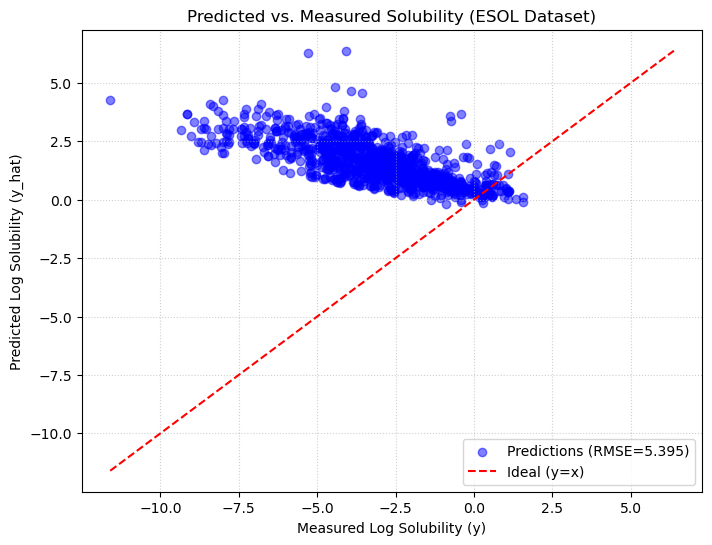

In [5]:
plt.figure(figsize=(8, 6))

# 画散点图
plt.scatter(all_targets, all_preds, alpha=0.5, color='blue', label=f'Predictions (RMSE={rmse:.3f})')

# 画 45 度理想线
min_val = min(all_targets.min(), all_preds.min())
max_val = max(all_targets.max(), all_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal (y=x)')

plt.xlabel('Measured Log Solubility (y)')
plt.ylabel('Predicted Log Solubility (y_hat)')
plt.title('Predicted vs. Measured Solubility (ESOL Dataset)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()